In [ ]:
%pip install puremacro


# La curva de Beveridge, en casa y fuera

**¿Cómo puede el desempleo ser alto mientras las empresas no logran
llenar vacantes?** La curva de Beveridge — vacantes contra desempleo —
es la cruz de oferta y demanda del mercado laboral (Blanchard-Diamond
1989). Los movimientos *a lo largo* de ella son el ciclo: los auges
suben hacia la izquierda (muchas vacantes, pocos desempleados), las
recesiones bajan hacia la derecha. Los movimientos *de* la curva son
estructurales: peor emparejamiento desplaza todo el lugar geométrico
hacia afuera. Tras el COVID la curva de EE.UU. quedó al centro de una
pelea de política económica — ¿podían caer las vacantes sin que subiera
el desempleo (Figura-Waller 2022), o la desinflación exigía una recesión
(Blanchard-Domash-Summers 2022)? Este notebook dibuja la evidencia con
los dos fetchers de vacantes del paquete: **JOLTS** para EE.UU.
(`puremacro.fetch.jolts`) y las **estadísticas de vacantes de Eurostat**
para Europa (`puremacro.fetch.vacancies_eurostat`), ambos congelados
aquí para uso sin red.

## La función de emparejamiento en matemáticas

El modelo de caballo de batalla (Pissarides 2000; panorama en
Petrongolo-Pissarides 2001) genera la curva desde una tecnología de
emparejamiento
$$ M_t = \mu\, U_t^{\alpha} V_t^{1-\alpha}, $$
contrataciones producidas con los acervos de buscadores $U$ y vacantes
$V$. Define la tensión $\theta = V/U$. La tasa de encuentro de empleo es
$$ f_t = M_t / U_t = \mu\, \theta_t^{1-\alpha}, $$
así que en un plano log-log de $f$ contra $\theta$ la pendiente ES
$1-\alpha$. En estado estacionario los flujos de entrada al desempleo
$s(1-u)$ igualan las salidas $f\,u$, lo que traza el lugar geométrico
decreciente
$$ u = \frac{s}{s + \mu \theta^{1-\alpha}} $$
— la curva de Beveridge. Más eficiencia de emparejamiento $\mu$ la
desplaza hacia adentro; más separaciones $s$ o más desajuste, hacia
afuera. JOLTS mide directamente cada objeto de estas ecuaciones:
vacantes ($V$), contrataciones ($M$), renuncias y despidos (las dos
caras de $s$).

**Intuición.** La curva es decreciente porque vacantes y desempleo son
dos caras de una misma fricción: cuando los puestos se llenan fácil,
pocas vacantes quedan abiertas y muchos trabajadores quedan ociosos;
cuando los trabajadores escasean, las vacantes se acumulan. La dirección
del *bucle* también informa — tras un choque la economía rodea la curva
en sentido antihorario, porque las vacantes se ajustan en semanas
mientras el estanque de desempleo se drena despacio. Y el episodio
estadounidense post-2021 es el experimento natural más limpio que la
curva haya producido: las vacantes cayeron desde máximos históricos casi
sin subida del desempleo — un descenso casi vertical que ninguno de los
dos lados del debate de 2022 predijo por completo.

## Preparación — dos paneles congelados

Congelados por `tools/gen_notebook_data_beveridge18.py` con los
fetchers del lote 5a (JOLTS vía fredgraph sin llave + `jvs_q_nace2` de
Eurostat vía la capa SDMX de la casa):

- `beveridge18_us.csv` — mensual SA: UNRATE, nivel de desempleo,
  vacantes/contrataciones/renuncias de JOLTS (niveles + tasas),
  diciembre de 2000 en adelante.
- `beveridge18_eu.csv` — trimestral: tasa de vacantes de Eurostat
  (NACE B-S, todos los tamaños, SA) unida con la tasa de desempleo LFS
  (convertida a por ciento), códigos ISO-3, 29 países.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.replication._data import load_csv

us = load_csv("beveridge18_us")
us["date"] = pd.to_datetime(us["date"])
eu = load_csv("beveridge18_eu")
eu["date"] = pd.to_datetime(eu["date"])
print(f"EE.UU.: {len(us)} meses {us['date'].min().date()}..{us['date'].max().date()}")
print(f"Europa: {eu['code'].nunique()} países, {len(eu)} país-trimestres")

ERAS = [
    ("2001-2007", "2000-12-01", "2007-11-30", "#2a78d6"),
    ("2008-2019", "2007-12-01", "2019-12-31", "#008300"),
    ("COVID 2020", "2020-01-01", "2020-12-31", "#e34948"),
    ("2021+", "2021-01-01", "2099-01-01", "#eda100"),
]

EE.UU.: 305 meses 2000-12-01..2026-05-01
Europa: 29 países, 1825 país-trimestres


## La curva de EE.UU., era por era

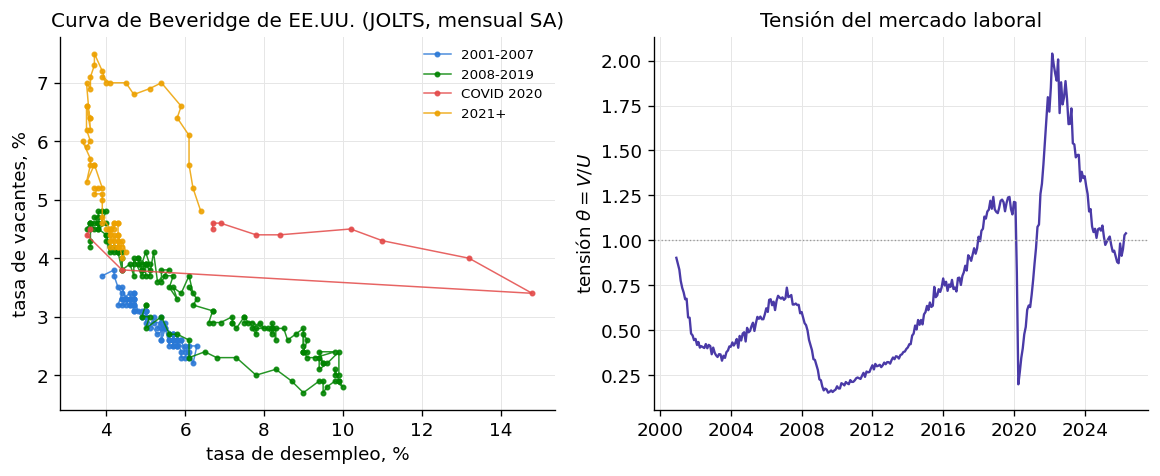

tensión máxima: 2.04 vacantes por desempleado (2022-03-01)


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.1))
ax = axes[0]
for name, lo, hi, c in ERAS:
    m = (us["date"] >= lo) & (us["date"] <= hi)
    ax.plot(us.loc[m, "urate"], us.loc[m, "v_rate"], "-o", color=c,
            ms=2.6, lw=0.9, alpha=0.85, label=name)
ax.set_xlabel("tasa de desempleo, %")
ax.set_ylabel("tasa de vacantes, %")
ax.set_title("Curva de Beveridge de EE.UU. (JOLTS, mensual SA)")
ax.legend(fontsize=8)

ax = axes[1]
us["theta"] = us["v_level"] / us["unemp_level"]
ax.plot(us["date"], us["theta"], color="#4a3aa7", lw=1.4)
ax.axhline(1.0, color="0.6", lw=0.8, ls=":")
ax.set_ylabel(r"tensión $\theta = V/U$")
ax.set_title("Tensión del mercado laboral")
plt.tight_layout(); plt.show()

peak_theta = us.loc[us["theta"].idxmax()]
print(f"tensión máxima: {peak_theta['theta']:.2f} vacantes por desempleado "
      f"({peak_theta['date'].date()})")
assert us["theta"].max() > 1.5, "el pico de tensión de 2022 debe superar 1.5"

**Leyendo el bucle.** La era 2008-2019 traza un circuito antihorario
completo: el desplome resbala hacia abajo-derecha sobre una curva
estable, la recuperación vuelve por un sendero visiblemente *exterior*
(el desplazamiento de 2010-13 que lanzó una literatura de desajuste), y
luego re-tensa. El COVID es el pico vertical — el desempleo se triplicó
en dos meses con vacantes casi quietas. El tramo 2021+ es el histórico:
la tensión llegó a unas dos vacantes por desempleado, y el descenso
desde ese pico corre casi en vertical — grandes caídas de vacantes,
mínima subida del desempleo.

## Estimando la elasticidad de emparejamiento

El proxy de tasa de encuentro $f = \text{contrataciones}/U$ contra la
tensión $\theta = V/U$, en logs: la pendiente estima $1-\alpha$. Dos
advertencias honestas incorporadas al printout: las contrataciones de
JOLTS incluyen cambios de empleo a empleo (numerador inflado), y el OLS
agregado ignora endogeneidad y agregación temporal — esta es la
regresión descriptiva de referencia de Petrongolo-Pissarides (2001), no
una estimación causal.

In [3]:
d = us.dropna(subset=["hires_level", "unemp_level", "theta"]).copy()
logf = np.log(d["hires_level"] / d["unemp_level"])
logth = np.log(d["theta"])
X = np.column_stack([np.ones(len(d)), logth])
b, *_ = np.linalg.lstsq(X, logf, rcond=None)
resid = logf - X @ b
r2 = 1 - resid.var() / logf.var()
alpha = 1 - b[1]
print(f"log f = {b[0]:+.3f} + {b[1]:.3f} log theta   (R2 {r2:.3f})")
print(f"=> elasticidad de emparejamiento alpha = {alpha:.3f}")
assert 0.2 < alpha < 0.9, "alpha debe caer en el rango amplio de la literatura"

log f = -0.195 + 0.592 log theta   (R2 0.877)
=> elasticidad de emparejamiento alpha = 0.408


## Europa: la misma curva, otras fricciones

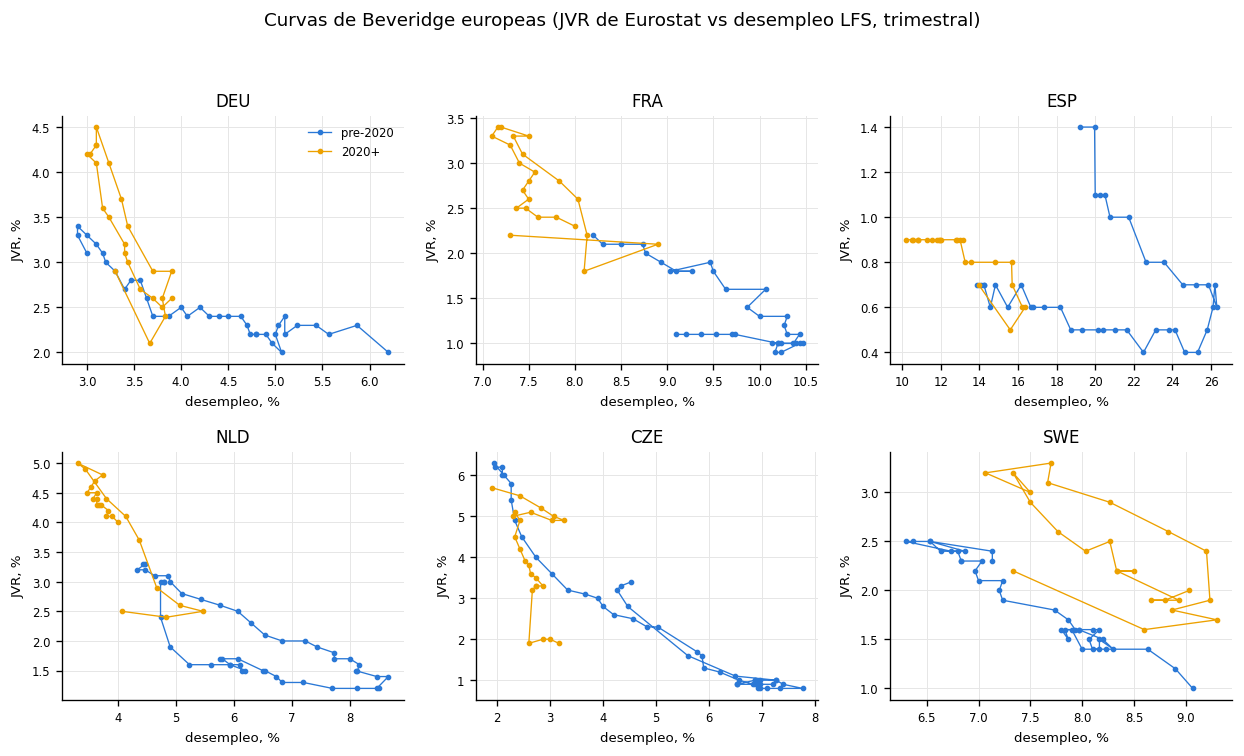

países graficados: ['DEU', 'FRA', 'ESP', 'NLD', 'CZE', 'SWE']


In [4]:
# Grandes economías primero (pedagogía), completado por cobertura.
_prefer = ["DEU", "FRA", "ESP", "NLD", "CZE", "SWE"]
_counts = eu.groupby("code")["date"].count()
top6 = [c for c in _prefer if _counts.get(c, 0) >= 30]
top6 += [c for c in _counts.sort_values(ascending=False).index
         if c not in top6][: 6 - len(top6)]
fig, axes = plt.subplots(2, 3, figsize=(10.5, 6.4), sharey=False)
for ax, code in zip(axes.ravel(), top6):
    g = eu[eu["code"] == code].sort_values("date")
    pre = g[g["date"] < "2020-01-01"]
    post = g[g["date"] >= "2020-01-01"]
    ax.plot(pre["urate"], pre["jvr"], "-o", color="#2a78d6", ms=2.4,
            lw=0.8, label="pre-2020")
    ax.plot(post["urate"], post["jvr"], "-o", color="#eda100", ms=2.4,
            lw=0.8, label="2020+")
    ax.set_title(code, fontsize=10)
    ax.set_xlabel("desempleo, %", fontsize=8)
    ax.set_ylabel("JVR, %", fontsize=8)
    ax.tick_params(labelsize=7)
axes[0, 0].legend(fontsize=7)
fig.suptitle("Curvas de Beveridge europeas (JVR de Eurostat vs desempleo "
             "LFS, trimestral)", fontsize=11)
plt.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()
print("países graficados:", top6)

**Lectura entre países.** La misma nube decreciente aparece en todas
partes, pero su *posición* difiere en un orden de magnitud en la
dirección de u: las economías con desempleo estructural alto operan muy
a la derecha con la misma tasa de vacantes — la fricción no es holgura
cíclica sino emparejamiento e instituciones. Los puntos 2020+ quedan
arriba y a la izquierda de la nube pre-2020 de cada país en la mayoría
de los paneles: el tensamiento post-COVID fue un fenómeno continental,
no una peculiaridad estadounidense.

## ¿Muerde más fuerte la incertidumbre en un mercado laboral holgado?

La curva nos da una *variable de régimen*: la tensión $\theta$. La
teoría sugiere que los choques deberían transmitirse distinto a lo
largo de la curva — en un mercado holgado (θ baja) un choque de
demanda o de incertidumbre encuentra trabajo ocioso abundante y
rigidez salarial; en uno tenso, sobre todo reacomoda vacantes. Las
proyecciones locales de transición suave del paquete
(`puremacro.lp.lp_state_dep`, la maquinaria del notebook 07) estiman
ambas respuestas a la vez, ponderando cada mes con una logística de
$\log\theta$ estandarizado. El choque aquí es el proxy EPU del panel
del notebook 17 (el mismo archivo congelado), con sus propios rezagos
como controles — dependencia de estado descriptiva, no una afirmación
estructural.

muestra mensual unida: 305 meses 2000-12-01..2026-05-01


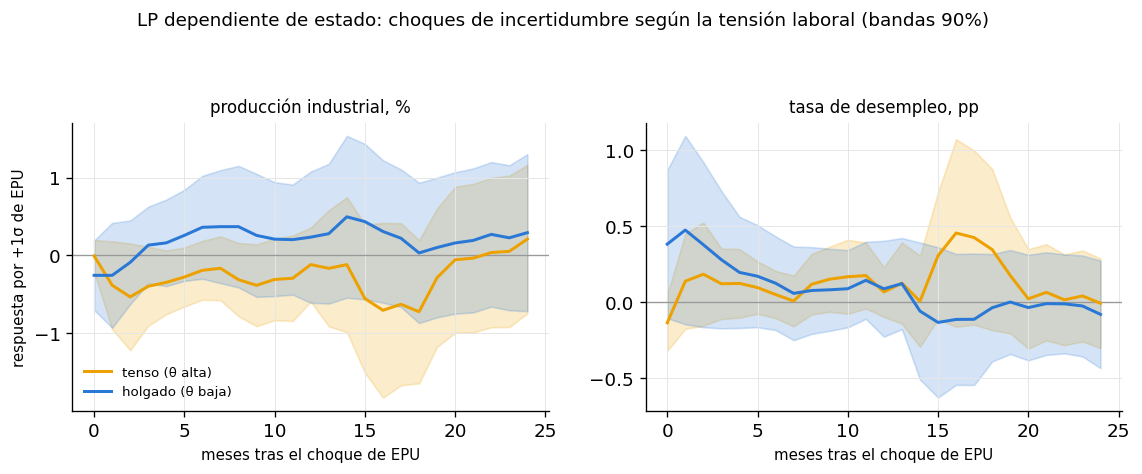

IP en h=12: holgado +0.24 [-0.61,+1.08] vs tenso -0.12 [-0.59,+0.36]


In [5]:
from puremacro.lp import lp_state_dep

spec = load_csv("speccurve17_panel")
spec["date"] = pd.to_datetime(spec["date"])
m = spec.merge(us[["date", "urate", "theta"]], on="date", how="inner")
m["log_theta"] = np.log(m["theta"])
print(f"muestra mensual unida: {len(m)} meses "
      f"{m['date'].min().date()}..{m['date'].max().date()}")

fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.0))
for ax, yvar, lab in ((axes[0], "ip", "producción industrial, %"),
                      (axes[1], "urate", "tasa de desempleo, pp")):
    r = lp_state_dep(m, y=yvar, x="epu", state="log_theta",
                     horizons=range(0, 25), n_lags=6)
    ax.axhline(0, color="0.6", lw=0.8)
    ax.fill_between(r["h"], r["lo_H"], r["hi_H"], color="#eda100",
                    alpha=0.20)
    ax.plot(r["h"], r["beta_H"], color="#eda100", lw=1.8,
            label="tenso (θ alta)")
    ax.fill_between(r["h"], r["lo_L"], r["hi_L"], color="#2a78d6",
                    alpha=0.20)
    ax.plot(r["h"], r["beta_L"], color="#2a78d6", lw=1.8,
            label="holgado (θ baja)")
    ax.set_xlabel("meses tras el choque de EPU", fontsize=9)
    ax.set_title(lab, fontsize=10)
axes[0].set_ylabel("respuesta por +1σ de EPU", fontsize=9)
axes[0].legend(fontsize=8)
fig.suptitle("LP dependiente de estado: choques de incertidumbre según "
             "la tensión laboral (bandas 90%)", fontsize=11)
plt.tight_layout(rect=(0, 0, 1, 0.92)); plt.show()

r_ip = lp_state_dep(m, y="ip", x="epu", state="log_theta",
                    horizons=[12], n_lags=6)
print(f"IP en h=12: holgado {r_ip['beta_L'].iloc[0]:+.2f} "
      f"[{r_ip['lo_L'].iloc[0]:+.2f},{r_ip['hi_L'].iloc[0]:+.2f}] vs "
      f"tenso {r_ip['beta_H'].iloc[0]:+.2f} "
      f"[{r_ip['lo_H'].iloc[0]:+.2f},{r_ip['hi_H'].iloc[0]:+.2f}]")

**Lectura honesta.** En esta muestra la respuesta es un nulo — y vale
la pena enseñarlo como tal. Ningún horizonte en ningún régimen es
significativo al 90%, y las estimaciones puntuales se inclinan en la
dirección *opuesta* al prior de "la incertidumbre muerde más en
mercados holgados": las respuestas de IP en régimen tenso son
levemente negativas, las de régimen holgado rondan cero. Con una sola
serie agregada, 25 años, un proxy sin identificar y pesos logísticos
que hacen que ambos regímenes compartan la mayoría de las
observaciones, esa es la resolución esperable — los hallazgos de
dependencia de estado de la literatura se apoyan en muestras más
largas, choques identificados o variación de panel (que es justo
donde entran el panel de distritos de Main Street y
`puremacro.lp.panel`). Las advertencias de inferencia del notebook 07
no son decoración; esta figura es su aspecto en la práctica.

## Tu turno — elige un país, parte una era

La partición por eras es en sí una decisión analítica. Cambia el país y
la fecha de corte: ¿la nube posterior de *tu* país queda dentro o fuera
de su curva previa? (Prueba "ESP" cortando en el pico de la crisis de
2013, o "CZE" en "2016-01-01" — la marcha hacia el mercado laboral más
tenso de Europa. Ojo: las series SA de vacantes empiezan 2008-2011, así
que cortes pre-crisis financiera no están disponibles en este freeze.)

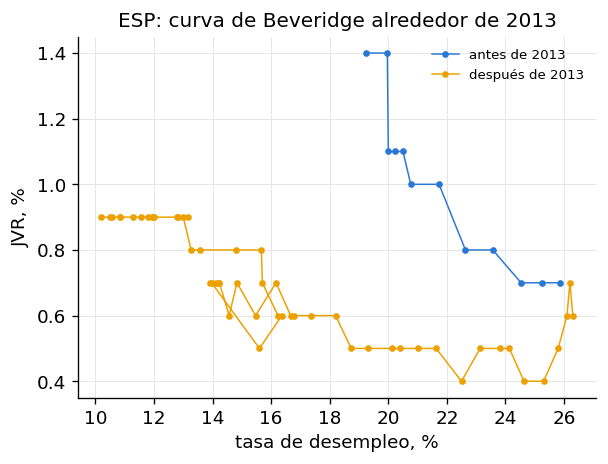

ESP: 12 trimestres antes, 52 después; desempleo medio 22.0% -> 16.7%


In [6]:
# ← Cambia estos:
COUNTRY_TRY = "ESP"
SPLIT_TRY = "2013-01-01"

g = eu[eu["code"] == COUNTRY_TRY].sort_values("date")
assert len(g) > 12, f"{COUNTRY_TRY}: pocos trimestres en el freeze"
pre = g[g["date"] < SPLIT_TRY]
post = g[g["date"] >= SPLIT_TRY]
fig, ax = plt.subplots(figsize=(5.2, 4.0))
if len(pre):
    ax.plot(pre["urate"], pre["jvr"], "-o", color="#2a78d6", ms=3,
            lw=0.9, label=f"antes de {SPLIT_TRY[:4]}")
ax.plot(post["urate"], post["jvr"], "-o", color="#eda100", ms=3, lw=0.9,
        label=f"después de {SPLIT_TRY[:4]}")
ax.set_xlabel("tasa de desempleo, %"); ax.set_ylabel("JVR, %")
ax.set_title(f"{COUNTRY_TRY}: curva de Beveridge alrededor de {SPLIT_TRY[:4]}")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"{COUNTRY_TRY}: {len(pre)} trimestres antes, {len(post)} después; "
      f"desempleo medio {pre['urate'].mean() if len(pre) else float('nan'):.1f}% "
      f"-> {post['urate'].mean():.1f}%")

**Ejercicios.** (1) *Básico*: colorea la nube de EE.UU. por `quits_rate`
en lugar de por era. ¿Por qué las renuncias siguen tan de cerca la
tensión que la "tasa de renuncias" se volvió sinónimo del poder de
negociación del trabajador? (2) *Intermedio*: re-estima la elasticidad
de emparejamiento solo con datos pre-2020 y luego con la muestra
completa. ¿Hacia dónde mueve el COVID a $\hat\alpha$, y qué dice eso de
mezclar regímenes de emparejamiento? (3) *Reto*: el lugar geométrico de
estado estacionario implica $u^{*} = s/(s + \mu\theta^{1-\alpha})$.
Recupera el $\mu_t$ implícito mes a mes desde JOLTS ($s$ desde despidos
+ renuncias, $f$ desde contrataciones/U), y pregunta si el descenso
vertical post-2021 fue $\mu$ recuperándose (Figura-Waller) o exceso de
demanda enfriándose (Blanchard et al.) — los datos de este notebook no
pueden separarlos del todo, que es exactamente por qué hubo debate.

**¿Qué tan completo es esto?** `puremacro.fetch.jolts` también sirve
contrataciones/renuncias/despidos por 13 supersectores (SA y NSA);
`fetch_eurostat_vacancies` sirve *conteos* de vacantes y puestos
ocupados por sección NACE y clase de tamaño; los paneles de desempleo
LFS (`fetch_eurostat_lfs_panel`, `fetch_oecd_lfs_panel`,
`fetch_labor_panel_union`) extienden el eje u a la OCDE; y las
proyecciones locales dependientes de estado del notebook 07
(`puremacro.lp`) son el siguiente paso natural para preguntar si los
choques importan distinto en las regiones tensas y holgadas de esta
curva.